# 01 - Hermione LoRA Training

Fine-tune Microsoft Phi-2 on Hermione Granger movie dialogue using LoRA, producing a character-style dialogue generator.

**Pipeline stage**: Stage 3 of the Character-Aware Dialogue Pipeline  
**Base model**: microsoft/phi-2 (2.7B params, 4bit quantized)  
**Method**: LoRA (rank=16, target q_proj & v_proj)  
**Dataset**: 600 Hermione movie lines with emotion labels  
**Output**: LoRA adapter weights + 100 generated responses for downstream emotion classifier training

## Phase 1 — Environment Setup

Load Phi-2 with 4bit quantization, attach LoRA adapters, and upload training data.

In [2]:
# Install the latest compatible versions
!pip install -q -U bitsandbytes
!pip install -q -U transformers
!pip install -q -U peft
!pip install -q -U accelerate
!pip install -q -U datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 93.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 55.4 MB/s eta 0:00:00


In [3]:
# Check bitsandbytes GPU support
import bitsandbytes as bnb
print("bitsandbytes version:", bnb.__version__)

# Try to create a GPU tensor with bitsandbytes
import torch
if torch.cuda.is_available():
    print("CUDA available:", True)
    print("CUDA version:", torch.version.cuda)

bitsandbytes version: 0.49.2
CUDA available: True
CUDA version: 12.8


In [4]:
#Load Phi2 model
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

# Configure 4bit quantization
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

model_name = "microsoft/phi-2"

tokenizer = AutoTokenizer.from_pretrained(
    model_name,
    trust_remote_code=True
)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)

print("Model loaded successfully")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/735 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model loaded successfully


In [5]:
# Prepare the quantized model for training
model = prepare_model_for_kbit_training(model)
print("Model is ready for LoRA training")

Model is ready for LoRA training


In [6]:
# Configure LoRA
lora_config = LoraConfig(
    r=16,                                    # Rank
    lora_alpha=32,                           # Scaling factor,  2 * r
    target_modules=["q_proj", "v_proj"],     # Apply LoRA only to attention Q and V projections
    lora_dropout=0.05,                       # Dropout
    bias="none",
    task_type="CAUSAL_LM",
)

# Attach LoRA modules to the model
model = get_peft_model(model, lora_config)

# Print the number of trainable parameters
model.print_trainable_parameters()

trainable params: 5,242,880 || all params: 2,784,926,720 || trainable%: 0.1883


In [9]:
import json

#upload hormione lines data

with open('/content/hermione_dataset_lora.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

print(f"Total number of samples: {len(data)}")
print(f"First sample:")
print(json.dumps(data[0], indent=2, ensure_ascii=False))

Total number of samples: 600
First sample:
{
  "instruction": "Respond as Hermione Granger in her characteristic voice and style.",
  "input": "[Emotional context: neutral]",
  "output": "Has anyone seen a toad? A boy named Neville's lost one.",
  "emotion": "neutral"
}


In [10]:
#sanity check

test_input = "What do you think about studying magic?"
inputs = tokenizer(test_input, return_tensors="pt").to("cuda")

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=50,
        do_sample=True,
        temperature=0.7,
    )

print("Model output:", tokenizer.decode(outputs[0], skip_special_tokens=True))

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Model output: What do you think about studying magic? Do you think it's important to understand the history and culture behind magic?"

Lily thought for a moment and said, "I think it's important to understand the history and culture behind magic because it helps us appreciate the art form even more


## Phase 2 — Training Pipeline Sanity Check

Run one short training pass on 100 samples to verify the training loop works and loss decreases before committing to full training.

In [11]:
import random

# Set random seed for reproducibility
random.seed(42)

# Sample 100 examples
sanity_data = random.sample(data, 100)

print(f"First sample:")
print(sanity_data[0])

First sample:
{'instruction': 'Respond as Hermione Granger in her characteristic voice and style.', 'input': '[Emotional context: determined]', 'output': "It's a cat, Ronald. What do you expect? It's in his nature.", 'emotion': 'determined'}


In [12]:
from datasets import Dataset

#AI generated

def format_sample(sample):
    # Combine instruction, input, and output into a single training text
    if sample.get("input"):
        text = (
            f"### Instruction:\n{sample['instruction']}\n\n"
            f"### Input:\n{sample['input']}\n\n"
            f"### Response:\n{sample['output']}"
        )
    else:
        text = (
            f"### Instruction:\n{sample['instruction']}\n\n"
            f"### Response:\n{sample['output']}"
        )
    return {"text": text}

# Sample 100 for sanity check
import random
random.seed(42)
sanity_data = random.sample(data, 100)

# Convert to Hugging Face Dataset
sanity_dataset = Dataset.from_list([format_sample(s) for s in sanity_data])

print("First formatted training text:")

print(sanity_dataset[0]['text'])


First formatted training text:
### Instruction:
Respond as Hermione Granger in her characteristic voice and style.

### Input:
[Emotional context: determined]

### Response:
It's a cat, Ronald. What do you expect? It's in his nature.


In [13]:
# Check token length distribution
token_lengths = [len(tokenizer(text["text"])["input_ids"]) for text in sanity_dataset]

print(f"Min length: {min(token_lengths)}")
print(f"Max length: {max(token_lengths)}")
print(f"Average length: {sum(token_lengths) / len(token_lengths):.1f}")
print(f"Samples exceeding 256 tokens: {sum(1 for l in token_lengths if l > 256)}")

Min length: 40
Max length: 121
Average length: 50.7
Samples exceeding 256 tokens: 0


In [14]:
# Tokenize with loss masking (only compute loss on Response)
def tokenize_function_with_masking(examples):
    #tokenize the full text normally
    result = tokenizer(
        examples["text"],
        truncation=True,
        max_length=128,
        padding="max_length",
    )

    # Find "### Response:\n" starts in each sample
    response_marker = "### Response:\n"
    labels = []

    for i, text in enumerate(examples["text"]):
        # Tokenize the full text and the prefix (before response) separately
        response_start_char = text.find(response_marker) + len(response_marker)
        prefix_text = text[:response_start_char]

        # Count tokens in the prefix
        prefix_tokens = tokenizer(prefix_text, add_special_tokens=False)["input_ids"]
        prefix_len = len(prefix_tokens)

        # Copy input_ids as labels, but mask the prefix part with -100
        sample_labels = result["input_ids"][i].copy()
        for j in range(min(prefix_len, len(sample_labels))):
            sample_labels[j] = -100

        # Also mask padding tokens (where attention_mask is 0)
        for j in range(len(sample_labels)):
            if result["attention_mask"][i][j] == 0:
                sample_labels[j] = -100

        labels.append(sample_labels)

    result["labels"] = labels
    return result

# Re-tokenize the dataset with loss masking
tokenized_dataset = sanity_dataset.map(
    tokenize_function_with_masking,
    batched=True,
    remove_columns=["text"],
)

print(f"Tokenized dataset size: {len(tokenized_dataset)}")
print(f"Fields: {tokenized_dataset.column_names}")

# Verify masking worked
sample_labels = tokenized_dataset[0]['labels']
num_masked = sum(1 for l in sample_labels if l == -100)
num_active = sum(1 for l in sample_labels if l != -100)
print(f"Masked tokens (prefix + padding): {num_masked}")
print(f"Active tokens (response): {num_active}")

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Tokenized dataset size: 100
Fields: ['input_ids', 'attention_mask', 'labels']
Masked tokens (prefix + padding): 110
Active tokens (response): 18


In [15]:
from transformers import TrainingArguments, Trainer

# Configure training arguments for the sanity check
training_args = TrainingArguments(
    output_dir="./sanity_check_output",
    num_train_epochs=1,                      # Only 1 epoch for sanity check
    per_device_train_batch_size=8,
    gradient_accumulation_steps=2,           # Effective batch size = 16
    learning_rate=2e-4,
    logging_steps=1,                         # Log loss every 5 steps
    save_strategy="no",                      # Do not save checkpoints
    report_to="none",                        # Disable external logging
    fp16=True,                               # for speed
    optim="paged_adamw_8bit",
    warmup_steps=5,                          # Warm up learning rate over 5 steps
    max_grad_norm=0.3,                       # Gradient clipping to prevent exploding gradients
)


In [16]:
# Create the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset,
)

# Start the sanity check training
trainer.train()


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss
1,3.771441
2,3.412394
3,3.751099
4,3.314193
5,3.819200
6,3.875822
7,3.519518


TrainOutput(global_step=7, training_loss=3.637666702270508, metrics={'train_runtime': 5.6123, 'train_samples_per_second': 17.818, 'train_steps_per_second': 1.247, 'total_flos': 203816042496000.0, 'train_loss': 3.637666702270508, 'epoch': 1.0})

## Phase 3 — Full Training with Hyperparameter Search

Train on the full 600-sample dataset across three learning rates (1e-4, 5e-4, 1e-3) for 3 epochs each. Select the run with the lowest validation loss as the final model.

In [17]:
import json
from collections import Counter

# Load LoRA train and validation data
with open('/content/lora_train.json', 'r', encoding='utf-8') as f:
    train_data = json.load(f)

with open('/content/lora_val.json', 'r', encoding='utf-8') as f:
    val_data = json.load(f)

print(f"Training samples: {len(train_data)}")
print(f"Validation samples: {len(val_data)}")

# Verify fields
print(f"\nTrain sample fields: {list(train_data[0].keys())}")
print(f"First sample:")
for key, value in train_data[0].items():
    print(f"  {key}: {value}")

# Show emotion distribution to verify stratified split
train_emotions = Counter([s['emotion'] for s in train_data])
val_emotions = Counter([s['emotion'] for s in val_data])
print(f"\nTrain emotion distribution: {dict(train_emotions)}")
print(f"Val emotion distribution: {dict(val_emotions)}")

Training samples: 537
Validation samples: 58

Train sample fields: ['instruction', 'input', 'output', 'emotion']
First sample:
  instruction: Respond as Hermione Granger in her characteristic voice and style.
  input: [Emotional context: worried]
  output: Harry, they went the wrong way!
  emotion: worried

Train emotion distribution: {'worried': 129, 'happy': 20, 'neutral': 207, 'determined': 110, 'angry': 56, 'sad': 15}
Val emotion distribution: {'neutral': 23, 'worried': 14, 'angry': 6, 'determined': 12, 'happy': 2, 'sad': 1}


In [18]:
from datasets import Dataset
#AI generated

def format_sample(sample):
    # Combine instruction, input, and output into training text
    text = (
        f"### Instruction:\n{sample['instruction']}\n\n"
        f"### Input:\n{sample['input']}\n\n"
        f"### Response:\n{sample['output']}"
    )
    return {"text": text}

# Convert to Hugging Face Dataset
train_dataset = Dataset.from_list([format_sample(s) for s in train_data])
val_dataset = Dataset.from_list([format_sample(s) for s in val_data])

print(f"Train dataset: {len(train_dataset)}")
print(f"Val dataset: {len(val_dataset)}")

# Tokenize with loss masking (same function from Phase 3.2)
def tokenize_function_with_masking(examples):
    result = tokenizer(
        examples["text"],
        truncation=True,
        max_length=128,
        padding="max_length",
    )

    response_marker = "### Response:\n"
    labels = []

    for i, text in enumerate(examples["text"]):
        response_start_char = text.find(response_marker) + len(response_marker)
        prefix_text = text[:response_start_char]

        prefix_tokens = tokenizer(prefix_text, add_special_tokens=False)["input_ids"]
        prefix_len = len(prefix_tokens)

        sample_labels = result["input_ids"][i].copy()
        for j in range(min(prefix_len, len(sample_labels))):
            sample_labels[j] = -100

        for j in range(len(sample_labels)):
            if result["attention_mask"][i][j] == 0:
                sample_labels[j] = -100

        labels.append(sample_labels)

    result["labels"] = labels
    return result

# Apply tokenization to both datasets
tokenized_train = train_dataset.map(
    tokenize_function_with_masking,
    batched=True,
    remove_columns=["text"],
)

tokenized_val = val_dataset.map(
    tokenize_function_with_masking,
    batched=True,
    remove_columns=["text"],
)

print(f"\nTokenized train size: {len(tokenized_train)}")
print(f"Tokenized val size: {len(tokenized_val)}")

# Verify masking on a sample
sample_labels = tokenized_train[0]['labels']
num_masked = sum(1 for l in sample_labels if l == -100)
num_active = sum(1 for l in sample_labels if l != -100)
print(f"\nSample 0: masked={num_masked}, active={num_active}")

Train dataset: 537
Val dataset: 58


Map:   0%|          | 0/537 [00:00<?, ? examples/s]

Map:   0%|          | 0/58 [00:00<?, ? examples/s]


Tokenized train size: 537
Tokenized val size: 58

Sample 0: masked=120, active=8


In [19]:
# Check active token distribution across samples
# AI generated
active_counts = []
for i in range(len(tokenized_train)):
    labels = tokenized_train[i]['labels']
    active = sum(1 for l in labels if l != -100)
    active_counts.append(active)

import statistics
print(f"Active token counts:")
print(f"  Min: {min(active_counts)}")
print(f"  Max: {max(active_counts)}")
print(f"  Mean: {statistics.mean(active_counts):.1f}")
print(f"  Median: {statistics.median(active_counts)}")
print(f"  Samples with <5 active tokens: {sum(1 for c in active_counts if c < 5)}")

Active token counts:
  Min: 4
  Max: 81
  Mean: 16.9
  Median: 12
  Samples with <5 active tokens: 2


In [20]:
import os
from transformers import TrainingArguments, Trainer

def train_one_run(learning_rate, run_name):
    """Train one LoRA run with a specific learning rate."""

    print(f"\n{'=' * 60}")
    print(f"Starting training: {run_name} (lr={learning_rate})")
    print(f"{'=' * 60}")

    # Output directory for this run
    output_dir = f"./lora_runs/{run_name}"

    # Training arguments
    training_args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=3,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        gradient_accumulation_steps=2,
        learning_rate=learning_rate,
        logging_steps=10,
        eval_strategy="epoch",                # Evaluate at end of each epoch
        save_strategy="epoch",                # Save checkpoint at end of each epoch
        save_total_limit=1,                  # Keep only the last checkpoint
        load_best_model_at_end=True,             # Load best model at end
        metric_for_best_model="eval_loss",       # Use eval loss to pick best
        greater_is_better=False,
        report_to="none",
        fp16=True,
        optim="paged_adamw_8bit",
        warmup_steps=10,
        max_grad_norm=0.3,
    )

    # Create Trainer with train + val datasets
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_val,
    )

    # Run training
    train_result = trainer.train()

    # Get final metrics
    final_train_loss = train_result.metrics["train_loss"]
    eval_result = trainer.evaluate()
    final_eval_loss = eval_result["eval_loss"]

    # Collect training history for loss curve plotting
    log_history = trainer.state.log_history

    print(f"\n{run_name} finished:")
    print(f"  Final train loss: {final_train_loss:.4f}")
    print(f"  Final eval loss: {final_eval_loss:.4f}")

    return {
        "run_name": run_name,
        "learning_rate": learning_rate,
        "final_train_loss": final_train_loss,
        "final_eval_loss": final_eval_loss,
        "log_history": log_history,
        "output_dir": output_dir,
    }

print("train_one_run function defined")

train_one_run function defined


In [21]:
import gc

def reset_model():
    """Reload Phi-2 and attach fresh LoRA adapters."""
    global model

    # Clean up memory
    del model
    gc.collect()
    torch.cuda.empty_cache()

    # Reload quantized Phi-2
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
    )

    model = AutoModelForCausalLM.from_pretrained(
        "microsoft/phi-2",
        quantization_config=bnb_config,
        device_map="auto",
        trust_remote_code=True,
    )

    model = prepare_model_for_kbit_training(model)

    # Attach fresh LoRA
    lora_config = LoraConfig(
        r=16,
        lora_alpha=32,
        target_modules=["q_proj", "v_proj"],
        lora_dropout=0.05,
        bias="none",
        task_type="CAUSAL_LM",
    )

    model = get_peft_model(model, lora_config)

    print(f"Model reset complete. GPU memory: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
    return model

print("reset_model function defined")

reset_model function defined


In [22]:
# Define three hyperparameter
runs_config = [
    {"lr": 1e-4, "name": "run_A_lr1e-4"},
    {"lr": 5e-4, "name": "run_B_lr5e-4"},
    {"lr": 1e-3, "name": "run_C_lr1e-3"},
]

# Store results from all runs
all_results = []

for config in runs_config:
    # Reset mode before each run
    model = reset_model()

    # Train with this learning rate
    result = train_one_run(
        learning_rate=config["lr"],
        run_name=config["name"],
    )

    all_results.append(result)

print("\n" + "=" * 60)
print("All three runs complete!")
print("=" * 60)

Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]

Model reset complete. GPU memory: 4.78 GB

Starting training: run_A_lr1e-4 (lr=0.0001)


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch,Training Loss,Validation Loss
1,3.205457,3.238750
2,3.191564,3.186935
3,3.129971,3.177426


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


...

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch,Training Loss,Validation Loss
1,3.084555,3.202218
2,3.012341,3.160400
3,2.791471,3.174625


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Training Loss,Validation Loss,Epoch
2.791471,3.160400,3



run_C_lr1e-3 finished:
  Final train loss: 3.0192
  Final eval loss: 3.1604

All three runs complete!


In [23]:
import pandas as pd

# Build a comparison table
comparison_data = []
for result in all_results:
    comparison_data.append({
        "run_name": result["run_name"],
        "learning_rate": result["learning_rate"],
        "final_train_loss": round(result["final_train_loss"], 4),
        "final_eval_loss": round(result["final_eval_loss"], 4),
    })

comparison_df = pd.DataFrame(comparison_data)
print("\nHyperparameter comparison:")
print(comparison_df.to_string(index=False))

# Save the comparison table
comparison_df.to_csv('/content/hyperparam_comparison.csv', index=False)
print("\nSaved to /content/hyperparam_comparison.csv")

# Find the best run based on eval loss
best_run = min(all_results, key=lambda x: x["final_eval_loss"])
print(f"\nBest run: {best_run['run_name']}")
print(f"Best learning rate: {best_run['learning_rate']}")
print(f"Best eval loss: {best_run['final_eval_loss']:.4f}")


Hyperparameter comparison:
    run_name  learning_rate  final_train_loss  final_eval_loss
run_A_lr1e-4         0.0001            3.2456           3.1774
run_B_lr5e-4         0.0005            3.0991           3.1279
run_C_lr1e-3         0.0010            3.0192           3.1604

Saved to /content/hyperparam_comparison.csv

Best run: run_B_lr5e-4
Best learning rate: 0.0005
Best eval loss: 3.1279


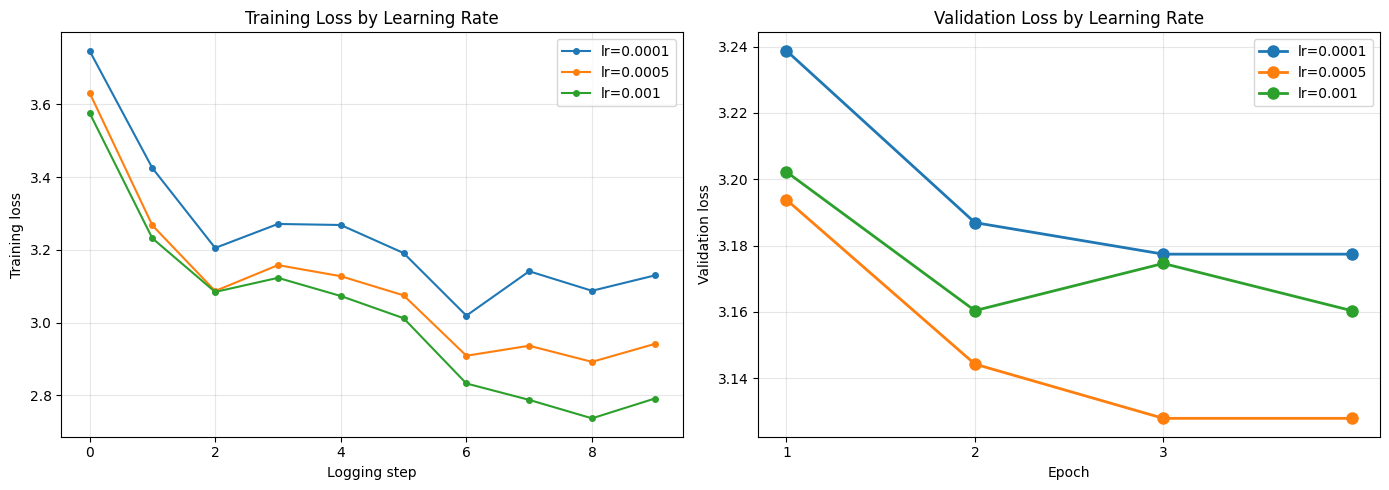

Saved training_loss_curves.png


In [24]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot training loss curves
for result in all_results:
    # Extract training loss entries from log history
    train_losses = [
        entry["loss"]
        for entry in result["log_history"]
        if "loss" in entry and "eval_loss" not in entry
    ]
    train_steps = list(range(len(train_losses)))
    axes[0].plot(
        train_steps,
        train_losses,
        label=f"lr={result['learning_rate']}",
        marker='o',
        markersize=4,
    )

axes[0].set_xlabel("Logging step")
axes[0].set_ylabel("Training loss")
axes[0].set_title("Training Loss by Learning Rate")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot eval loss curves
for result in all_results:
    eval_losses = [
        entry["eval_loss"]
        for entry in result["log_history"]
        if "eval_loss" in entry
    ]
    eval_epochs = list(range(1, len(eval_losses) + 1))
    axes[1].plot(
        eval_epochs,
        eval_losses,
        label=f"lr={result['learning_rate']}",
        marker='o',
        markersize=8,
        linewidth=2,
    )

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation loss")
axes[1].set_title("Validation Loss by Learning Rate")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks([1, 2, 3])

plt.tight_layout()
plt.savefig('/content/training_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved training_loss_curves.png")

**Final Model Training (Selected lr=5e-4)**


**Selection rationale**:
- **lr=1e-4** (Run A): Final val loss = 3.1774. Too conservative, loss plateaued without sufficient learning signal.
- **lr=5e-4** (Run B): Final val loss = **3.1279 (lowest)**. Monotonic decrease across all 3 epochs, stable training dynamics.
- **lr=1e-3** (Run C): Final val loss = 3.1604. Train loss was lowest (2.79), but **validation loss reverted at epoch 3** (3.16 → 3.17), indicating early signs of overfitting.

**Why re-train instead of reusing Run B weights**: After the hyperparameter loop finished, the model in memory was from the last run (Run C, lr=1e-3). We re-train from a fresh LoRA initialization with lr=5e-4 to ensure the saved final model is clean and corresponds exactly to our selected configuration.

In [25]:
# Reset model to a fresh LoRA state
print("Resetting model for final training run...")
model = reset_model()

# Use the best learning rate identified in hyperparameter search
best_lr = best_run["learning_rate"]
print(f"\nFinal training config:")
print(f"  Learning rate: {best_lr}")
print(f"  Epochs: 3")
print(f"  Batch size: 8 (with grad accum 2, effective 16)")
print(f"  Max sequence length: 128")
print()

# Configure training arguments for the final model
final_training_args = TrainingArguments(
    output_dir="./lora_final_model",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    learning_rate=best_lr,
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none",
    fp16=True,
    optim="paged_adamw_8bit",
    warmup_steps=10,
    max_grad_norm=0.3,
)

# Create Trainer
final_trainer = Trainer(
    model=model,
    args=final_training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
)

# Run final training
print("Starting final model training...")
final_train_result = final_trainer.train()

# Evaluate one more time
final_eval = final_trainer.evaluate()

print("\n" + "=" * 60)
print("Final model training complete!")
print(f"Final train loss: {final_train_result.metrics['train_loss']:.4f}")
print(f"Final eval loss: {final_eval['eval_loss']:.4f}")
print("=" * 60)

Resetting model for final training run...


Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]

Model reset complete. GPU memory: 6.35 GB

Final training config:
  Learning rate: 0.0005
  Epochs: 3
  Batch size: 8 (with grad accum 2, effective 16)
  Max sequence length: 128

Starting final model training...


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch,Training Loss,Validation Loss
1,3.087138,3.193815
2,3.075209,3.144289
3,2.941632,3.127935


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Training Loss,Validation Loss,Epoch
2.941632,3.127935,3



Final model training complete!
Final train loss: 3.0991
Final eval loss: 3.1279


## Phase 4 — Evaluate on 30 Test Questions

Use the best LoRA model to answer the 30 predefined test questions from Phase 2. Save outputs for later comparison against the API baseline.

In [27]:
with open('/content/test_questions.json', 'r', encoding='utf-8') as f:
    test_questions = json.load(f)

# Check category distribution
from collections import Counter
categories = Counter([q["category"] for q in test_questions])
print(f"\nCategory distribution: {dict(categories)}")

# Check target emotion distribution
primary_emotions = Counter([q["target_emotion"].split("/")[0] for q in test_questions])
print(f"Primary target emotions: {dict(primary_emotions)}")


Category distribution: {'academic': 10, 'friendship': 10, 'moral dilemma': 10}
Primary target emotions: {'determined': 3, 'angry': 8, 'neutral': 4, 'happy': 2, 'worried': 10, 'sad': 3}


In [28]:
# Verify model is still in memory and working
try:
    # Quick test
    test_prompt = (
        "### Instruction:\n"
        "Respond as Hermione Granger in her characteristic voice and style.\n\n"
        "### Input:\n"
        "[Emotional context: determined] What is the correct wand movement for the Levitation Charm?\n\n"
        "### Response:\n"
    )
    inputs = tokenizer(test_prompt, return_tensors="pt").to("cuda")

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=50,
            do_sample=True,
            temperature=0.7,
            pad_token_id=tokenizer.eos_token_id,
        )

    print("Model working. Test output:")
    print(tokenizer.decode(outputs[0], skip_special_tokens=True)[-200:])
except NameError:
    print("Model not loaded")

Model working. Test output:
ponse:
It's all about the flick. You've got to flick it at just the right angle. But watch out -- that's the hardest part.  You've got to flick it so hard you'll probably break your wand.  And, if you


In [29]:
def generate_response(question, emotion, max_tokens=60, temperature=0.5, top_p=0.9):
    """Generate a Hermione-style response with anti-repetition controls.

    Args:
        question: The user input question or situation
        emotion: Single emotion label
        max_tokens: Maximum new tokens (reduced to limit rambling)
        temperature: Lower temperature for more focused output
        top_p: Nucleus sampling parameter

    Returns:
        Generated response text
    """
    prompt = (
        f"### Instruction:\n"
        f"Respond as Hermione Granger in her characteristic voice and style.\n\n"
        f"### Input:\n"
        f"[Emotional context: {emotion}] {question}\n\n"
        f"### Response:\n"
    )

    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_tokens,
            do_sample=True,
            temperature=temperature,
            top_p=top_p,
            repetition_penalty=1.3,              # Penalize repeated tokens
            no_repeat_ngram_size=3,              # Forbid repeating 3-grams
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    full_output = tokenizer.decode(outputs[0], skip_special_tokens=True)
    response = full_output.split("### Response:\n")[-1].strip()

    # Truncate at any new section marker
    for delimiter in ["### Instruction:", "### Input:", "### Response:"]:
        if delimiter in response:
            response = response.split(delimiter)[0].strip()

    # Truncate at last complete sentence (if max_tokens cut mid-sentence)
    # Find the last sentence-ending punctuation
    for punct in [".", "!", "?"]:
        last_idx = response.rfind(punct)
        if last_idx > len(response) * 0.5:  # Only truncate if we keep >50% of content
            response = response[:last_idx + 1].strip()
            break

    return response


# Quick test on the problematic Q1
test_response = generate_response(
    question="What is the correct wand movement for the Levitation Charm?",
    emotion="determined",
)
print(f"Test Q1 (determined): {test_response}")

Test Q1 (determined): It's a bit tricky, Harry -- but you'll get it with practice! You need to keep your eye on Ron.  And make sure he doesn't touch his wands at any point during this spell...


In [30]:
# Test on three previously problematic questions
test_cases = [
    {"q": "What is the correct wand movement for the Levitation Charm?", "e": "determined"},
    {"q": "How do you prepare for the O.W.L. exams?", "e": "determined"},
    {"q": "What's the most interesting book you've read recently?", "e": "happy"},
]

print("Testing new generation parameters:\n")
for case in test_cases:
    response = generate_response(case["q"], case["e"])
    print(f"Q: {case['q']}")
    print(f"Emotion: {case['e']}")
    print(f"A: {response}")
    print("-" * 70)

Testing new generation parameters:

Q: What is the correct wand movement for the Levitation Charm?
Emotion: determined
A: The first step, of course!  It's not a trick -- it really works... if you do it right. It takes practice to get used to using your wand correctly; but once you've got that down pat, there are plenty more tricks up its sleeve....
----------------------------------------------------------------------
Q: How do you prepare for the O.W.L. exams?
Emotion: determined
A: Well, it's not too hard once you know what to expect!  You have a few days' notice before they start -- so make sure your potions are up-to-date...and don't forget to study some Defense Against the Dark Arts just in case.
----------------------------------------------------------------------
Q: What's the most interesting book you've read recently?
Emotion: happy
A: The Sword of Gryffindor! It was a real eye-opener, wasn't it Harry Potter?  It showed us what we're capable of when our minds are focused on s

In [31]:
import json
from tqdm import tqdm

# Regenerate neutral responses with improved parameters
print("Regenerating neutral responses...")
responses_neutral = []
for q in tqdm(test_questions):
    response = generate_response(q["question"], emotion="neutral")
    responses_neutral.append({
        "id": q["id"],
        "category": q["category"],
        "question": q["question"],
        "target_emotion": q["target_emotion"],
        "emotion_used": "neutral",
        "response": response,
    })

with open('/content/lora_responses_neutral.json', 'w', encoding='utf-8') as f:
    json.dump(responses_neutral, f, ensure_ascii=False, indent=2)

# Regenerate emotion-conditioned responses
print("\nRegenerating emotion-conditioned responses...")
responses_emotional = []
for q in tqdm(test_questions):
    primary_emotion = q["target_emotion"].split("/")[0]
    response = generate_response(q["question"], emotion=primary_emotion)
    responses_emotional.append({
        "id": q["id"],
        "category": q["category"],
        "question": q["question"],
        "target_emotion": q["target_emotion"],
        "emotion_used": primary_emotion,
        "response": response,
    })

with open('/content/lora_responses_emotional.json', 'w', encoding='utf-8') as f:
    json.dump(responses_emotional, f, ensure_ascii=False, indent=2)

print(f"\nDone! {len(responses_neutral)} neutral + {len(responses_emotional)} emotional responses saved.")

Regenerating neutral responses...


100%|██████████| 30/30 [02:47<00:00,  5.59s/it]



Regenerating emotion-conditioned responses...


100%|██████████| 30/30 [02:46<00:00,  5.55s/it]


Done! 30 neutral + 30 emotional responses saved.


In [32]:
import pandas as pd

# Build comparison table
comparison_rows = []
for neutral, emotional in zip(responses_neutral, responses_emotional):
    comparison_rows.append({
        "id": neutral["id"],
        "category": neutral["category"],
        "question": neutral["question"],
        "target_emotion": neutral["target_emotion"],
        "neutral_response": neutral["response"],
        "emotional_response": emotional["response"],
        "emotion_used_emotional": emotional["emotion_used"],
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv('/content/lora_responses_comparison.csv', index=False, encoding='utf-8')
print(f"Saved comparison table\n")

# Print all 30 for review
print("=" * 80)
print("ALL 30 RESPONSES (improved generation)")
print("=" * 80)

for neutral, emotional in zip(responses_neutral, responses_emotional):
    print(f"\n--- Q{neutral['id']} [{neutral['category']}] (target: {neutral['target_emotion']}) ---")
    print(f"Question: {neutral['question']}")
    print(f"\n[NEUTRAL]:   {neutral['response']}")
    print(f"[{emotional['emotion_used'].upper()}]: {emotional['response']}")
    print("-" * 80)

Saved comparison table

ALL 30 RESPONSES (improved generation)

--- Q1 [academic] (target: determined) ---
Question: What is the correct wand movement for the Levitation Charm?

[NEUTRAL]:   The first step of this spell requires you to hold your wands at a 45 degree angle, with one end touching both hands -- but not too tightly! The second part involves making two quick circles around each other while saying 'Bubbe'...
[DETERMINED]: I think it's this -- a flick of your wrist, like you're flicking off an eyelash...  The other way to do it would be with two hands on top one another holding them straight up...
--------------------------------------------------------------------------------

--- Q2 [academic] (target: angry/determined) ---
Question: Ron just said vampires turn into bats during the day.

[NEUTRAL]:   That's not true, Harry!  It happens when they're asleep... but only if you have a wand strong enough to touch them while sleeping." --Ron Weasley  In this case it was actually 

In [33]:
from google.colab import files

files.download('/content/lora_responses_neutral.json')
files.download('/content/lora_responses_emotional.json')
files.download('/content/lora_responses_comparison.csv')

# Backup to Drive
backup_dir = '/content/drive/MyDrive/hermione_project_backups/phase3_4'
!mkdir -p "$backup_dir"
!cp /content/lora_responses_neutral.json "$backup_dir/"
!cp /content/lora_responses_emotional.json "$backup_dir/"
!cp /content/lora_responses_comparison.csv "$backup_dir/"

print(f"Backed up to {backup_dir}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Backed up to /content/drive/MyDrive/hermione_project_backups/phase3_4


## Phase 5 — Generate 100 Samples for Classifier Training

Prompt the trained model with 100 new inputs to produce unlabeled dialogue samples. These will be used in Phase 4 for the distribution-shift test and to augment the emotion classifier training set.

In [34]:
# 100 diverse prompts for generating Hermione responses
all_prompts = [
    # determined (20 samples)
    {"emotion": "determined", "context": "I will master this spell no matter how long it takes."},
    {"emotion": "determined", "context": "We have to go after Sirius right now!"},
    {"emotion": "determined", "context": "This essay deserves more than a perfect O grade."},
    {"emotion": "determined", "context": "Reading every chapter before class is not optional."},
    {"emotion": "determined", "context": "Harry needs to study Defense Against the Dark Arts before the duel."},
    {"emotion": "determined", "context": "We can solve this without help if we just think clearly."},
    {"emotion": "determined", "context": "I'm not letting Snape intimidate any first-year again."},
    {"emotion": "determined", "context": "There must be a charm in the library that can fix this."},
    {"emotion": "determined", "context": "We're going to find that Horcrux tonight."},
    {"emotion": "determined", "context": "I refuse to fail this Transfiguration test."},
    {"emotion": "determined", "context": "Ron, you need to practice that levitation spell properly."},
    {"emotion": "determined", "context": "Standing up to Umbridge is the right thing to do."},
    {"emotion": "determined", "context": "I'm going to organize a defense club whether the Ministry likes it or not."},
    {"emotion": "determined", "context": "We have to brew the Polyjuice Potion correctly this time."},
    {"emotion": "determined", "context": "I'll spend every weekend in the library if that's what it takes."},
    {"emotion": "determined", "context": "Free the house-elves, every single one of them."},
    {"emotion": "determined", "context": "I'll prove that Crookshanks is innocent."},
    {"emotion": "determined", "context": "We must finish this map before Filch catches us."},
    {"emotion": "determined", "context": "Every spell in this book has to be memorized by Friday."},
    {"emotion": "determined", "context": "I'm not leaving until I find the answer."},

    # worried (18 samples)
    {"emotion": "worried", "context": "Harry hasn't returned from the Forbidden Forest yet."},
    {"emotion": "worried", "context": "Ron's wand is acting strangely after Lockhart's spell."},
    {"emotion": "worried", "context": "The Dementors are getting closer to Hogwarts."},
    {"emotion": "worried", "context": "I think someone tampered with my potion."},
    {"emotion": "worried", "context": "Crookshanks has been missing all night."},
    {"emotion": "worried", "context": "Harry's scar is hurting again."},
    {"emotion": "worried", "context": "What if the troll comes back to the dungeon?"},
    {"emotion": "worried", "context": "Have you seen Neville? He didn't come to Charms."},
    {"emotion": "worried", "context": "I haven't finished my Arithmancy homework and class is in an hour."},
    {"emotion": "worried", "context": "Do you think the basilisk is still in the school?"},
    {"emotion": "worried", "context": "What if my parents never remember me?"},
    {"emotion": "worried", "context": "I lost my notes for the Astronomy exam."},
    {"emotion": "worried", "context": "Hagrid hasn't shown up for class today."},
    {"emotion": "worried", "context": "Harry, I think we're being followed."},
    {"emotion": "worried", "context": "What if Dumbledore is actually wrong about this?"},
    {"emotion": "worried", "context": "The Time-Turner is acting strange."},
    {"emotion": "worried", "context": "Ron's broken arm looks worse than yesterday."},
    {"emotion": "worried", "context": "I think someone read my diary."},

    # angry (16 samples)
    {"emotion": "angry", "context": "Malfoy just called me a know-it-all again!"},
    {"emotion": "angry", "context": "Ron, you forgot the Polyjuice Potion ingredients!"},
    {"emotion": "angry", "context": "Skeeter's article is full of lies!"},
    {"emotion": "angry", "context": "How could you not finish your Charms homework?"},
    {"emotion": "angry", "context": "Snape took ten points just because I knew the answer."},
    {"emotion": "angry", "context": "You broke my time-turner with your foolishness!"},
    {"emotion": "angry", "context": "Filch confiscated my notes for absolutely no reason."},
    {"emotion": "angry", "context": "Cormac McLaggen has been bothering me all week."},
    {"emotion": "angry", "context": "Ron, you'd rather copy my homework than do it yourself?"},
    {"emotion": "angry", "context": "Umbridge gave me detention for asking a question."},
    {"emotion": "angry", "context": "Don't you dare touch my books without asking."},
    {"emotion": "angry", "context": "How could anyone call house-elves happy with their lot?"},
    {"emotion": "angry", "context": "You let the cat out of the common room again!"},
    {"emotion": "angry", "context": "Ron, that broom is more important to you than I am?"},
    {"emotion": "angry", "context": "Harry, you cannot keep risking your life every term!"},
    {"emotion": "angry", "context": "Malfoy bullied a first-year right in front of me."},

    # happy (12 samples)
    {"emotion": "happy", "context": "Harry, we won the House Cup!"},
    {"emotion": "happy", "context": "Hagrid showed me the new baby unicorns."},
    {"emotion": "happy", "context": "I finally cast the Patronus Charm correctly!"},
    {"emotion": "happy", "context": "Mum sent me a new copy of Hogwarts: A History."},
    {"emotion": "happy", "context": "Today's the trip to Hogsmeade!"},
    {"emotion": "happy", "context": "Professor McGonagall said my essay was brilliant."},
    {"emotion": "happy", "context": "I got a perfect score on my Potions exam!"},
    {"emotion": "happy", "context": "Ron and Harry both passed their Charms test!"},
    {"emotion": "happy", "context": "Crookshanks finally let me brush him."},
    {"emotion": "happy", "context": "S.P.E.W. has its first official member!"},
    {"emotion": "happy", "context": "I made the Charms Club president!"},
    {"emotion": "happy", "context": "We're going to the Yule Ball tonight!"},

    # sad (10 samples)
    {"emotion": "sad", "context": "Crookshanks didn't recognize me when I came back."},
    {"emotion": "sad", "context": "I miss my parents during Christmas at Hogwarts."},
    {"emotion": "sad", "context": "Dobby's funeral was so quiet."},
    {"emotion": "sad", "context": "Ron and Lavender are holding hands again."},
    {"emotion": "sad", "context": "The library closed before I could finish my research."},
    {"emotion": "sad", "context": "I had to obliviate my parents."},
    {"emotion": "sad", "context": "Hedwig didn't make it home."},
    {"emotion": "sad", "context": "I haven't heard from Viktor in months."},
    {"emotion": "sad", "context": "Sometimes I feel like I don't fit in anywhere."},
    {"emotion": "sad", "context": "Fred is gone, Ron. I'm so sorry."},

    # neutral (24 samples)
    {"emotion": "neutral", "context": "We have Herbology after lunch."},
    {"emotion": "neutral", "context": "The Quidditch match starts at three."},
    {"emotion": "neutral", "context": "I'll be in the library if anyone needs me."},
    {"emotion": "neutral", "context": "The Sorting Hat song mentioned house unity again."},
    {"emotion": "neutral", "context": "Dinner is almost over in the Great Hall."},
    {"emotion": "neutral", "context": "Today's Charms class covered Cheering Charms."},
    {"emotion": "neutral", "context": "Professor Flitwick canceled office hours."},
    {"emotion": "neutral", "context": "The Daily Prophet had three articles about you today."},
    {"emotion": "neutral", "context": "Ron is in detention until six."},
    {"emotion": "neutral", "context": "Morning rounds end in twenty minutes."},
    {"emotion": "neutral", "context": "Harry, your scar moved on the Marauder's Map."},
    {"emotion": "neutral", "context": "There's a new chapter in Hogwarts: A History this edition."},
    {"emotion": "neutral", "context": "The owl post arrived an hour ago."},
    {"emotion": "neutral", "context": "Madam Pince closed the Restricted Section."},
    {"emotion": "neutral", "context": "Tomorrow's lesson is on Vanishing Spells."},
    {"emotion": "neutral", "context": "The corridor on the third floor is locked again."},
    {"emotion": "neutral", "context": "Filch posted new rules on the notice board."},
    {"emotion": "neutral", "context": "Ginny is on the Quidditch team this year."},
    {"emotion": "neutral", "context": "The greenhouses got a shipment of new mandrakes."},
    {"emotion": "neutral", "context": "Padma sat next to me in Arithmancy today."},
    {"emotion": "neutral", "context": "The lesson plan for next week is on the board."},
    {"emotion": "neutral", "context": "I finished all the assigned reading this morning."},
    {"emotion": "neutral", "context": "We have a free period before lunch."},
    {"emotion": "neutral", "context": "I checked out three new books from the library."},
]

# Add metadata
for i, p in enumerate(all_prompts):
    p["source"] = "synthetic"
    p["id"] = i + 1

print(f"Total prompts: {len(all_prompts)}")

# Show distribution
from collections import Counter
emotion_dist = Counter([p["emotion"] for p in all_prompts])
print(f"Emotion distribution: {dict(emotion_dist)}")

Total prompts: 100
Emotion distribution: {'determined': 20, 'worried': 18, 'angry': 16, 'happy': 12, 'sad': 10, 'neutral': 24}


In [39]:
def generate_with_context(emotion, context="", max_tokens=60, temperature=0.5, top_p=0.9):
    """Generate a Hermione-style response with optional context input."""

    # Build the input field: combine emotion tag with optional context
    input_text = f"[Emotional context: {emotion}]"
    if context:
        input_text += f" {context}"

    prompt = (
        f"### Instruction:\n"
        f"Respond as Hermione Granger in her characteristic voice and style.\n\n"
        f"### Input:\n"
        f"{input_text}\n\n"
        f"### Response:\n"
    )

    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_tokens,
            do_sample=True,
            temperature=temperature,
            top_p=top_p,
            repetition_penalty=1.3,
            no_repeat_ngram_size=3,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    full_output = tokenizer.decode(outputs[0], skip_special_tokens=True)
    response = full_output.split("### Response:\n")[-1].strip()

    # Truncate at section markers
    for delimiter in ["### Instruction:", "### Input:", "### Response:"]:
        if delimiter in response:
            response = response.split(delimiter)[0].strip()

    # Truncate at last sentence-ending punctuation
    for punct in [".", "!", "?"]:
        last_idx = response.rfind(punct)
        if last_idx > len(response) * 0.5:
            response = response[:last_idx + 1].strip()
            break

    return response


In [40]:
from tqdm import tqdm

# Generate 100 responses
print("Generating 100 LoRA responses...")
generated_samples = []

for prompt_config in tqdm(all_prompts):
    response = generate_with_context(
        emotion=prompt_config["emotion"],
        context=prompt_config["context"],
    )

    generated_samples.append({
        "id": prompt_config["id"],
        "source_emotion": prompt_config["emotion"],
        "context_used": prompt_config["context"],
        "source": prompt_config["source"],
        "response": response,
    })

print(f"\nGenerated {len(generated_samples)} responses")

# Show first 5
for s in generated_samples[:5]:
    print(f"\n[{s['source_emotion']}] {s['context_used']}")
    print(f"-> {s['response']}")

Generating 100 LoRA responses...


100%|██████████| 100/100 [09:17<00:00,  5.57s/it]


Generated 100 responses

[determined] I will master this spell no matter how long it takes.
-> I'm sure you can do that, Harry!  It's not hard once the steps are memorized -- just like everything else we've learned at Hogwarts...

[determined] We have to go after Sirius right now!
-> No, we can't do that -- it's too dangerous...  We need a plan first. And you've got your wand on the floor? You're going to grab it before I say anything else?!

[determined] This essay deserves more than a perfect O grade.
-> It's due tomorrow, Harry! I can't believe you're still working on it -- the night before its deadline...  You'll never make up for lost sleep with all this studying we've been doing lately; don't ruin your summer vacation by trying to cram everything into one week.

[determined] Reading every chapter before class is not optional.
-> I know, I've been trying to read it all night -- but... Harry's gone!  He just left the room without saying a word or even looking at me when he came ba

In [41]:
!pip install -q openai

In [ ]:
import os
os.environ['OPENAI_API_KEY'] = 'you key here' #your key here

In [43]:
from openai import OpenAI
import time
from tqdm import tqdm

client = OpenAI()

VALID_EMOTIONS = ["determined", "worried", "angry", "happy", "sad", "neutral"]

# Use the complete annotation guidelines as system prompt
ANNOTATION_GUIDELINES = """What you need to do
you are going to read a line said by Hermione Granger from Harry Potter movies. your job is put one emotion label on it. only one label per line.

the six labels you can choose from:

determined
worried
angry
happy
sad
neutral

do not invent new labels. if you're not sure, just pick the closest one.

Core rules:
work line by line. dont try to infer context from other lines.
if you see a line and you have no idea, go with neutral.
be consistant. if you labeled one type of line determined the first time, do the same thing the 500th time.
dont overthink it. 3 seconds per line is fine.

definition for each label

determined
this is when Hermione is confident, pushing forward, making a plan, correcting someone, or explaining something she knows. a LOT of her lines fall into this. she's a know-it-all so this should be common.
example:
"It's leviOsa, not levioSAH."
"We can't be seen, Harry."
"I read about this in Hogwarts, A History."

if she sounds like she's in charge or teaching, its determined.

worried
she is scared, anxious, nervous, or thinking about something bad that might happen. future-oriented fear usually. she mentions a problem or a risk.
example:
"What if they catch us?"
"This isn't good. This really isn't good."
"I don't like this, Harry."

worried vs sad is tricky. worried is about something that might happen. sad is about something that already happened.

angry
she is mad, annoyed, yelling at someone, or snapping. usually short and sharp. often directed at ron.
exampels:
"Ronald!"
"How dare you!"
"That is the most ridiculous thing I've ever heard."

happy
she is glad, laughing, celebrating, relieved, or complimenting someone. not super common actually, hermione isn't a super happy character. but sometimes.
example:
"Oh Harry, we did it!"
"That was brilliant, Ron."

sad
something bad already happened. she is crying, mourning, disappointed, or feeling hopeless. PAST oriented.
examples:
"I can't believe he's gone."
"I just... I don't know what to do anymore."

neutral (USE SPARINGLY)

CRITICAL: Do NOT use neutral as a default or safe choice. Most Hermione lines have some emotional undertone.

ONLY use neutral if ALL of these are true:
- The line is a pure factual statement with no emotional coloring
- No urgency, no worry, no assertion, no frustration
- It would sound identical if said by any character

Examples of TRUE neutral (rare):
- "Yes." (as acknowledgment)
- "It's on the third floor."

Examples that are NOT neutral (common mistakes):
- "We need to go now" -> determined (urgency)
- "Harry, listen" -> determined (assertion)
- "I don't think so" -> worried or determined depending on context

If you're choosing between neutral and ANY other label, choose the other label.

priority rules (when two emotions could fit)
sometimes a line can feel like two emotions at the same time. here are the rules:

determined beats worried. if she's worried but still giving a plan, its determined. example: "We need to find it before they do" sounds worried but its a plan, so -> determined.
angry beats sad. if she's crying AND yelling, pick angry. because angry is more action-y.
neutral is the last resort. don't pick neutral just because you're lazy. only pick it when really nothing else fits.
if its still a tie, pick the one that would be more useful for image generation. because that's the downstream task. so determined/angry/worried are more useful than happy/sad/neutral (they have stronger visual signals).
angry is about other people or things that make her frustrated (e.g., Ron being lazy, Malfoy being cruel). worried is about threats or bad outcomes (e.g., getting caught, failing exams). If the line is about a person -> probably angry. If the line is about a future event -> probably worried

things to watch for:
sometimes Hermione corrects someone (like ron). thats NOT angry, thats determined. she's not mad, she's teaching.
rhetorical questions can be angry OR worried depending on tone. "How could you?" is angry. "What are we going to do?" is worried.
if the line is super short like "Honestly!" use the context clue in the line itself. "Honestly!" on its own -> angry (she's frustrated). but you only get the line, no context, so just go with the tone.
dont confuse excited with happy. excited about a plan -> determined. excited because something good happened -> happy.

output format
just output the label. lowercase, no punctuation, no explanation.
like this:
determined
not like this:
The emotion is: Determined.
and not this either:
determined (because she's giving a plan)
just the word. one word. lowercase.

examples for calibration
read these 10 examples to get the feeling before you start:

"I read about it in Hogwarts, a History." -> determined
"Harry, we shouldn't be here." -> worried
"You're a prat, Ronald Weasley." -> angry
"Oh Harry, I was so worried about you." -> happy (she's relieved, which is happy-adjacent)
"He's gone, Harry. He's really gone." -> sad
"It's on the third floor." -> neutral
"We have to go NOW." -> determined (urgency + action plan)
"What if it doesn't work?" -> worried
"How could you do this to me?" -> angry
"Yes, Professor." -> neutral

if you disagree with any of these you're probably calibrated wrong. re-read the definitions."""


def label_emotion(text, max_retries=3):
    """Use GPT-4o-mini to classify emotion using the full Hermione annotation guidelines."""

    for attempt in range(max_retries):
        try:
            response = client.chat.completions.create(
                model="gpt-4o-mini",
                messages=[
                    {"role": "system", "content": ANNOTATION_GUIDELINES},
                    {"role": "user", "content": text},
                ],
                temperature=0,
                max_tokens=10,
            )

            label = response.choices[0].message.content.strip().lower()

            # Validate
            if label in VALID_EMOTIONS:
                return label

            # Fuzzy match if model included extra text
            for emotion in VALID_EMOTIONS:
                if emotion in label:
                    return emotion

            return "neutral"

        except Exception as e:
            if attempt < max_retries - 1:
                time.sleep(2)
            else:
                print(f"Failed after {max_retries} attempts: {e}")
                return "neutral"

# Quick test on the calibration examples
print("Testing on calibration examples:")
test_cases = [
    ("I read about it in Hogwarts, a History.", "determined"),
    ("Harry, we shouldn't be here.", "worried"),
    ("You're a prat, Ronald Weasley.", "angry"),
    ("It's on the third floor.", "neutral"),
    ("What if it doesn't work?", "worried"),
]

correct = 0
for text, expected in test_cases:
    predicted = label_emotion(text)
    status = "✓" if predicted == expected else "✗"
    if predicted == expected:
        correct += 1
    print(f"  {status} '{text}' -> predicted: {predicted}, expected: {expected}")

print(f"\nCalibration accuracy: {correct}/{len(test_cases)}")

Testing on calibration examples:
  ✓ 'I read about it in Hogwarts, a History.' -> predicted: determined, expected: determined
  ✓ 'Harry, we shouldn't be here.' -> predicted: worried, expected: worried
  ✓ 'You're a prat, Ronald Weasley.' -> predicted: angry, expected: angry
  ✓ 'It's on the third floor.' -> predicted: neutral, expected: neutral
  ✓ 'What if it doesn't work?' -> predicted: worried, expected: worried

Calibration accuracy: 5/5


In [44]:
import json

print("Labeling 100 LoRA-generated responses with GPT-4o-mini using full guidelines...")

for sample in tqdm(generated_samples):
    sample["predicted_emotion"] = label_emotion(sample["response"])

# Save labeled data
with open('/content/lora_generated_100.json', 'w', encoding='utf-8') as f:
    json.dump(generated_samples, f, ensure_ascii=False, indent=2)

print(f"\nLabeled and saved {len(generated_samples)} samples")

Labeling 100 LoRA-generated responses with GPT-4o-mini using full guidelines...


100%|██████████| 100/100 [00:52<00:00,  1.90it/s]


Labeled and saved 100 samples


In [45]:
import pandas as pd
from collections import Counter

# Build a DataFrame for analysis
df = pd.DataFrame(generated_samples)

print("=" * 60)
print("EMOTION DISTRIBUTION COMPARISON")
print("=" * 60)

source_dist = Counter(df['source_emotion'])
predicted_dist = Counter(df['predicted_emotion'])

print(f"{'Emotion':<15}{'Intended':<15}{'Actual':<15}{'Diff':<10}")
print("-" * 55)
for emotion in VALID_EMOTIONS:
    intended = source_dist.get(emotion, 0)
    actual = predicted_dist.get(emotion, 0)
    diff = actual - intended
    sign = "+" if diff > 0 else ""
    print(f"{emotion:<15}{intended:<15}{actual:<15}{sign}{diff:<10}")

# Compute intent-output match rate
matches = sum(1 for s in generated_samples if s['source_emotion'] == s['predicted_emotion'])
match_rate = matches / len(generated_samples)
print(f"\nIntent-Output match rate: {match_rate:.1%} ({matches}/100)")

# Per-emotion match rate
print("\nPer-emotion match rate:")
print("-" * 50)
for emotion in VALID_EMOTIONS:
    samples_with_intent = [s for s in generated_samples if s['source_emotion'] == emotion]
    if samples_with_intent:
        emotion_matches = sum(1 for s in samples_with_intent if s['predicted_emotion'] == emotion)
        emotion_rate = emotion_matches / len(samples_with_intent)
        print(f"  {emotion:<15} {emotion_matches}/{len(samples_with_intent)} ({emotion_rate:.1%})")

# Confusion matrix
print("\nConfusion matrix (rows=intended, cols=predicted):")
confusion = pd.crosstab(
    df['source_emotion'],
    df['predicted_emotion'],
    margins=True,
    margins_name='Total',
)
print(confusion)

# Save the confusion matrix
confusion.to_csv('/content/lora_generation_confusion.csv', encoding='utf-8')
print("\nSaved confusion matrix to lora_generation_confusion.csv")

EMOTION DISTRIBUTION COMPARISON
Emotion        Intended       Actual         Diff      
-------------------------------------------------------
determined     20             26             +6         
worried        18             41             +23        
angry          16             5              -11       
happy          12             12             0         
sad            10             3              -7        
neutral        24             13             -11       

Intent-Output match rate: 41.0% (41/100)

Per-emotion match rate:
--------------------------------------------------
  determined      12/20 (60.0%)
  worried         12/18 (66.7%)
  angry           2/16 (12.5%)
  happy           6/12 (50.0%)
  sad             3/10 (30.0%)
  neutral         6/24 (25.0%)

Confusion matrix (rows=intended, cols=predicted):
predicted_emotion  angry  determined  happy  neutral  sad  worried  Total
source_emotion                                                           
angry        

In [46]:
import random

# Sample 10 random examples for manual inspection
random.seed(42)
inspect_samples = random.sample(generated_samples, 10)

print("=" * 80)
print("MANUAL INSPECTION OF 10 RANDOM SAMPLES")
print("=" * 80)

for s in inspect_samples:
    print(f"--- ID {s['id']} ---")
    print(f"Context: {s['context_used']}")
    print(f"Intended: {s['source_emotion']}  |  Predicted: {s['predicted_emotion']}")
    print(f"Response: {s['response']}")
    print()

MANUAL INSPECTION OF 10 RANDOM SAMPLES
--- ID 82 ---
Context: Today's Charms class covered Cheering Charms.
Intended: neutral  |  Predicted: happy
Response: That was the one that made people cheer, wasn't it?  The one you used to make your friends laugh when they were feeling down...'It'll be alright.

--- ID 15 ---
Context: I'll spend every weekend in the library if that's what it takes.
Intended: determined  |  Predicted: worried
Response: I think you've got to be careful, Harry.  We don't want anyone else finding out about this... The Ministry of Magic is very interested in anything related to Voldemort -- especially any information on his whereabouts or plans for revenge against Dumbledore!

--- ID 4 ---
Context: Reading every chapter before class is not optional.
Intended: determined  |  Predicted: worried
Response: I know, I've been trying to read it all night -- but... Harry's gone!  He just left the room without saying a word or even looking at me when he came back from his cla